In [48]:
import heapq
import random
import sys
from itertools import combinations
from typing import List, Tuple

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
from scipy.spatial import KDTree
from shapely.geometry import LineString, Point, Polygon
from shapely.ops import split

IS_FILE_INPUT = True
ONLINE_JUDGE = True if len(sys.argv) >= 2 and sys.argv[1] == "ONLINE_JUDGE" else False


def prim(
    graph: dict[int, list[tuple[int, int]]],
) -> tuple[list[tuple[int, int]], list[int]]:
    """
    G: 隣接グラフ
    G := [ [(v_0, cost_0), (v_1,cost_1),..], [(v_2, cost_2)],...]

    返り値 ans :最小全域木の重みの総和
    """
    v_list = list(graph.keys())
    used = {v: False for v in v_list}

    init_v = v_list[0]  # 適当な点を選ぶ
    used[init_v] = True
    que = [(cost, init_v, v) for v, cost in graph[init_v]]
    heapq.heapify(que)

    ans_v: list[int] = [init_v]
    ans_edges: list[tuple[int, int]] = []
    while que:
        cost_v, from_v, to_v = heapq.heappop(que)
        if used[to_v]:
            continue
        used[to_v] = True
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        for nxt, cost_nxt in graph[to_v]:
            if used[nxt]:
                continue
            heapq.heappush(que, (cost_nxt, to_v, nxt))
    return ans_edges, ans_v


class Env:
    def __init__(self, input_file_path: str):
        with open(input_file_path) as f:
            lines = f.readlines()
            N, M, Q, L, W = map(int, lines[0].split())
            G = list(map(int, lines[1].split()))
            rectangles = []
            for l in range(2, 2 + N):
                rectangles.append(list(map(int, lines[l].split())))
            coordinates = []
            for l in range(2 + N, 2 + N + N):
                coordinates.append(list(map(int, lines[l].split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.coordinates = coordinates
        self.cneter_points = [[(l + r) / 2, (c + d) / 2] for l, r, c, d in rectangles]
        self._query_history: list[str] = []

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        self._query_history.append(query_str)

        now_graph: dict[int, list] = {v: [] for v in c_list}
        for c1 in c_list:
            for c2 in c_list:
                if c1 == c2:
                    continue
                x1, y1 = self.coordinates[c1]
                x2, y2 = self.coordinates[c2]
                dist = abs(x1 - x2) ** 2 + abs(y1 - y2) ** 2
                now_graph[c1].append((c2, dist))
                now_graph[c2].append((c1, dist))

        ans_edges, ans_v = prim(now_graph)
        return ans_edges

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
        output_file_path: str,
    ):
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"

        with open(output_file_path, "w") as f:
            for query_str in self._query_history:
                f.write(query_str + "\n")
            f.write(ans_str)

    def _input(self):
        W, D, N = map(int, input().split())
        a = []
        for d in range(D):
            a.append(list(map(int, input().split())))
        return W, D, N, a


def solve(env: Env):
    N, M, Q, L, W = env.N, env.M, env.Q, env.L, env.W
    G = env.G
    rectangles = env.rectangles
    lx, rx, ly, ry = [], [], [], []
    for n in range(N):
        a, b, c, d = rectangles[n]
        lx.append(a)
        rx.append(b)
        ly.append(c)
        ry.append(d)

    # use center of rectangle
    x = [(l + r) // 2 for l, r in zip(lx, rx)]
    y = [(l + r) // 2 for l, r in zip(ly, ry)]

    # split cities into groups
    cities = list(range(N))
    cities.sort(key=lambda i: (x[i], y[i]))
    groups = []
    start_idx = 0
    for g in G:
        groups.append(cities[start_idx : start_idx + g])
        start_idx += g

    # get edges from queries
    edges = []
    for k in range(M):
        edges.append([])
        for i in range(0, G[k] - 1, 2):
            if i < G[k] - 2:
                ret = env.query(groups[k][i : i + 3])
                edges[k].extend(ret)
            else:
                edges[k].append(groups[k][i : i + 2])

    env.answer(groups, edges, "../out/0000.txt")


env = Env("../in/0000.txt")


In [49]:
N_POINT = 60
N_PAIR = 15
CUT_RATIO = 0.01


def calc_dist(p1: tuple, p2: tuple) -> float:
    x_dff = p1[0] - p2[0]
    y_dff = p1[1] - p2[1]
    dist = (x_dff**2 + y_dff**2) ** 0.5
    return dist


def fast_greedy_pairing(points: List[Tuple[float, float]]) -> List[Tuple[int, int]]:
    points = np.array(points)
    n = len(points)
    used = np.zeros(n, dtype=bool)
    tree = KDTree(points)
    pairs = []

    for i in range(n):
        if used[i]:
            continue
        dists, indices = tree.query(points[i], k=min(30, n))
        for j in indices[1:]:
            if not used[j]:
                pairs.append((i, int(j)))
                used[i] = used[j] = True
                break

    return pairs


def farthest_greedy_pairing(points: List[Tuple[float, float]]) -> List[Tuple[int, int]]:
    points = np.array(points)
    n = len(points)
    used = np.zeros(n, dtype=bool)
    pairs = []

    # 全てのペアとその距離を計算
    dists = []
    for i, j in combinations(range(n), 2):
        dist = np.linalg.norm(points[i] - points[j])
        dists.append((dist, i, j))

    # 距離が大きい順にソート
    dists.sort(reverse=True)

    # 距離が大きい順にペアリング
    for _, i, j in dists:
        if not used[i] and not used[j]:
            pairs.append((i, j))
            used[i] = used[j] = True

    return pairs


def farthest_point_sampling(points: np.ndarray, M: int) -> np.ndarray:
    N = len(points)
    selected_indices = []

    idx = np.random.randint(0, N)
    selected_indices.append(idx)
    min_distances = np.full(N, np.inf)

    for _ in range(1, M):
        last_point = points[selected_indices[-1]]
        distances = np.linalg.norm(points - last_point, axis=1)
        min_distances = np.minimum(min_distances, distances)
        next_idx = np.argmax(min_distances)
        selected_indices.append(int(next_idx))

    return selected_indices


def select_pairs(cneter_points, rectangles):
    diffs = []
    for v, (l, r, t, b) in enumerate(rectangles):
        diffs.append((v, abs(l - r) + abs(t - b)))

    sorted_diffs = sorted(diffs, key=lambda x: x[1])

    target_diffs = sorted_diffs[:N_POINT]
    target_inds = [diff[0] for diff in target_diffs]
    target_points = [cneter_points[diff[0]] for diff in target_diffs]
    pairs = fast_greedy_pairing(target_points)
    pairs = [(target_inds[i], target_inds[j]) for i, j in pairs]
    pair_centers = []
    for v, q in pairs:
        pair_centers.append(
            [
                (cneter_points[v][0] + cneter_points[q][0]) / 2,
                (cneter_points[v][1] + cneter_points[q][1]) / 2,
            ]
        )
    sample_inds = farthest_point_sampling(np.array(pair_centers), N_PAIR)
    selected_pairs = []
    for i in sample_inds:
        selected_pairs.append(pairs[i])
    return selected_pairs

- ゆらぎの少ない 2 点で、かつ、2 点の間が小さいものを基準にする
- その 2 点の垂直二等分線でポリゴンが切れて、2 点がなすひし形とかぶらないポリゴンを見つけてくる
- そのポリゴンの中で最も面積の大きいポリゴンを選択
  - できれば平等に分割できるポリゴンがうれしい
    - 適当に 10%以上で分割できることとする？
- 3 点クエリを行い、本当の点がどこに存在するかを求める
- 上記を 400 回繰り返す

800 _ 400
3.2 _ 10^5


In [50]:
def _extend_line_fixed_bounds(cut_string: LineString, bounds_min=-1000, bounds_max=11000):
    # ベクトルの方向を正規化
    cut_point1, cut_point2 = cut_string.coords
    p1 = np.array(cut_point1)
    p2 = np.array(cut_point2)
    direction = p2 - p1
    direction = direction / np.linalg.norm(direction)

    # 直線の延長距離を大きくとる
    length = (bounds_max - bounds_min) * 2
    new_p1 = p1 - direction * length
    new_p2 = p2 + direction * length

    return LineString([new_p1, new_p2])


def split_polygon_with_extended_line(polygon, cut_string):
    cutting_line = _extend_line_fixed_bounds(cut_string)
    result = split(polygon, cutting_line)
    polygons = [geom for geom in result.geoms if isinstance(geom, Polygon)]
    return polygons


def perpendicular_bisector(point1, point2):
    """
    垂直二等分線
    """
    p1 = np.array(point1)
    p2 = np.array(point2)

    midpoint = (p1 + p2) / 2
    vec = p2 - p1
    norm = np.linalg.norm(vec)
    perp_vec = np.array([-vec[1], vec[0]]) / norm
    start = midpoint - perp_vec
    end = midpoint + perp_vec

    return LineString([start, end])


def create_my_custom_rect(point1, point2):
    """
    point1とpoint2を結ぶ線分と直角に交わる線分を利用して正方形を作る
    """
    p1 = np.array(point1)
    p2 = np.array(point2)

    midpoint = (p1 + p2) / 2
    vec = p2 - p1
    norm = np.linalg.norm(vec)
    perp_vec = np.array([-vec[1], vec[0]]) / norm**2
    square_points = [
        tuple(p1 - perp_vec),
        tuple(p1 + perp_vec),
        tuple(p2 + perp_vec),
        tuple(p2 - perp_vec),
    ]

    return Polygon(square_points)


class MyPolygon:
    def __init__(self, rect_points, ind):
        l, r, t, b = rect_points
        points = [
            (l, t),
            (r, t),
            (r, b),
            (l, b),
        ]
        self.polygon = Polygon(points)
        self.ind = ind

    def area(self):
        return self.polygon.area

    def is_cutting(self, cut_point1, cut_point2):
        cut_string = perpendicular_bisector(cut_point1, cut_point2)
        result_polygons = split_polygon_with_extended_line(self.polygon, cut_string)
        # custom_rect = create_my_custom_rect(cut_point1, cut_point2)
        if len(result_polygons) == 2:  # and (not self.polygon.intersects(custom_rect)):
            return min(result_polygons[0].area, result_polygons[1].area)
        return False

    def cut(self, cut_point1, cut_point2, target_cut):
        cut_string = perpendicular_bisector(cut_point1, cut_point2)
        result_polygons = split_polygon_with_extended_line(self.polygon, cut_string)
        boundary1 = result_polygons[0].boundary
        boundary2 = result_polygons[1].boundary

        if Point(target_cut).distance(boundary1) < Point(target_cut).distance(boundary2):
            self.polygon = result_polygons[0]
        else:
            self.polygon = result_polygons[1]

In [51]:
def calc_rectangle_area(rectangle):
    l, r, t, b = rectangle
    area = (r - l) * (b - t)
    return area

In [52]:
FILE_NUM = 100
file_num = 1

input_file_path = f"../in/{file_num:04d}.txt"
env = Env(input_file_path)

In [53]:
selected_pairs = select_pairs(env.cneter_points, env.rectangles)
selected_pair_coordinates = []
for i, j in selected_pairs:
    selected_pair_coordinates.append((i, j, env.cneter_points[i], env.cneter_points[j]))

polygon_heap = []
my_polygons: dict[int, MyPolygon] = {}
for v, (l, r, t, b) in enumerate(env.rectangles):
    polygon_heap.append((-calc_rectangle_area(env.rectangles[v]), v))
    my_polygons[v] = MyPolygon(env.rectangles[v], v)
heapq.heapify(polygon_heap)

In [54]:
cut_num = 0
while polygon_heap and cut_num < 400:
    poly_area, poly_ind = heapq.heappop(polygon_heap)
    poly = my_polygons[poly_ind]
    max_area = 0
    cut_pair = None
    for p1, p2, c1, c2 in selected_pair_coordinates:
        cutting_area = poly.is_cutting(c1, c2)
        if cutting_area:
            if cutting_area > max_area:
                max_area = cutting_area
                cut_pair = (p1, p2, c1, c2)
    if cut_pair and max_area > CUT_RATIO * -poly_area:
        p1, p2, c1, c2 = cut_pair
        q = env.query([p1, p2, poly.ind])
        q_vs = list(q[0]) + list(q[1])
        if q_vs.count(p1) == 2:
            target_cut = c1, p1
        elif q_vs.count(p2) == 2:
            target_cut = c2, p2
        else:
            continue
        poly.cut(c1, c2, target_cut[0])
        print(poly.ind, p1, p2, target_cut)
        new_poly_area = poly.area()
        my_polygons[poly_ind] = poly
        heapq.heappush(polygon_heap, (-new_poly_area, poly_ind))
        cut_num += 1

525 795 386 ([6133.0, 6113.0], 386)
524 711 539 ([721.5, 1284.5], 539)
331 781 260 ([5439.0, 4350.0], 781)
135 781 260 ([4848.0, 3584.0], 260)
648 781 260 ([5439.0, 4350.0], 781)
471 303 427 ([348.0, 8993.0], 303)
734 161 612 ([9953.0, 1782.0], 161)
73 94 266 ([40.0, 4144.0], 266)
471 94 266 ([40.0, 4144.0], 266)
559 155 10 ([7340.5, 4604.5], 155)
351 711 539 ([913.5, 2159.5], 711)
783 668 327 ([8739.0, 8152.0], 668)
218 711 539 ([913.5, 2159.5], 711)
104 781 260 ([4848.0, 3584.0], 260)
174 408 470 ([3914.0, 2620.0], 408)
685 155 10 ([8283.0, 4726.0], 10)
281 668 327 ([8739.0, 8152.0], 668)
122 268 747 ([4024.5, 9230.5], 268)
203 94 266 ([876.0, 3686.0], 94)
491 781 260 ([4848.0, 3584.0], 260)
712 781 260 ([4848.0, 3584.0], 260)
757 268 747 ([6475.5, 7650.5], 747)
23 668 327 ([8739.0, 8152.0], 668)
657 408 470 ([3914.0, 2620.0], 408)
595 161 612 ([9953.0, 1782.0], 161)
274 668 327 ([8739.0, 8152.0], 668)
54 43 335 ([3177.0, 4344.0], 43)
348 668 327 ([8739.0, 8152.0], 668)
101 161 612 (

In [55]:
estimate_coordinate = []
for n in range(env.N):
    x, y = my_polygons[n].polygon.centroid.xy
    estimate_coordinate.append((x[0], y[0]))

In [56]:
diffs = []
for n in range(env.N):
    p1 = env.cneter_points[n]
    p2 = env.coordinates[n]
    diff = calc_dist(p1, p2)
    diffs.append(diff)
print("average diff:", sum(diffs) / len(diffs))

average diff: 326.33828810006287


In [57]:
diffs = []
for n in range(env.N):
    p1 = estimate_coordinate[n]
    p2 = env.coordinates[n]
    diff = calc_dist(p1, p2)
    diffs.append(diff)
print("average diff:", sum(diffs) / len(diffs))

average diff: 330.02836832074854


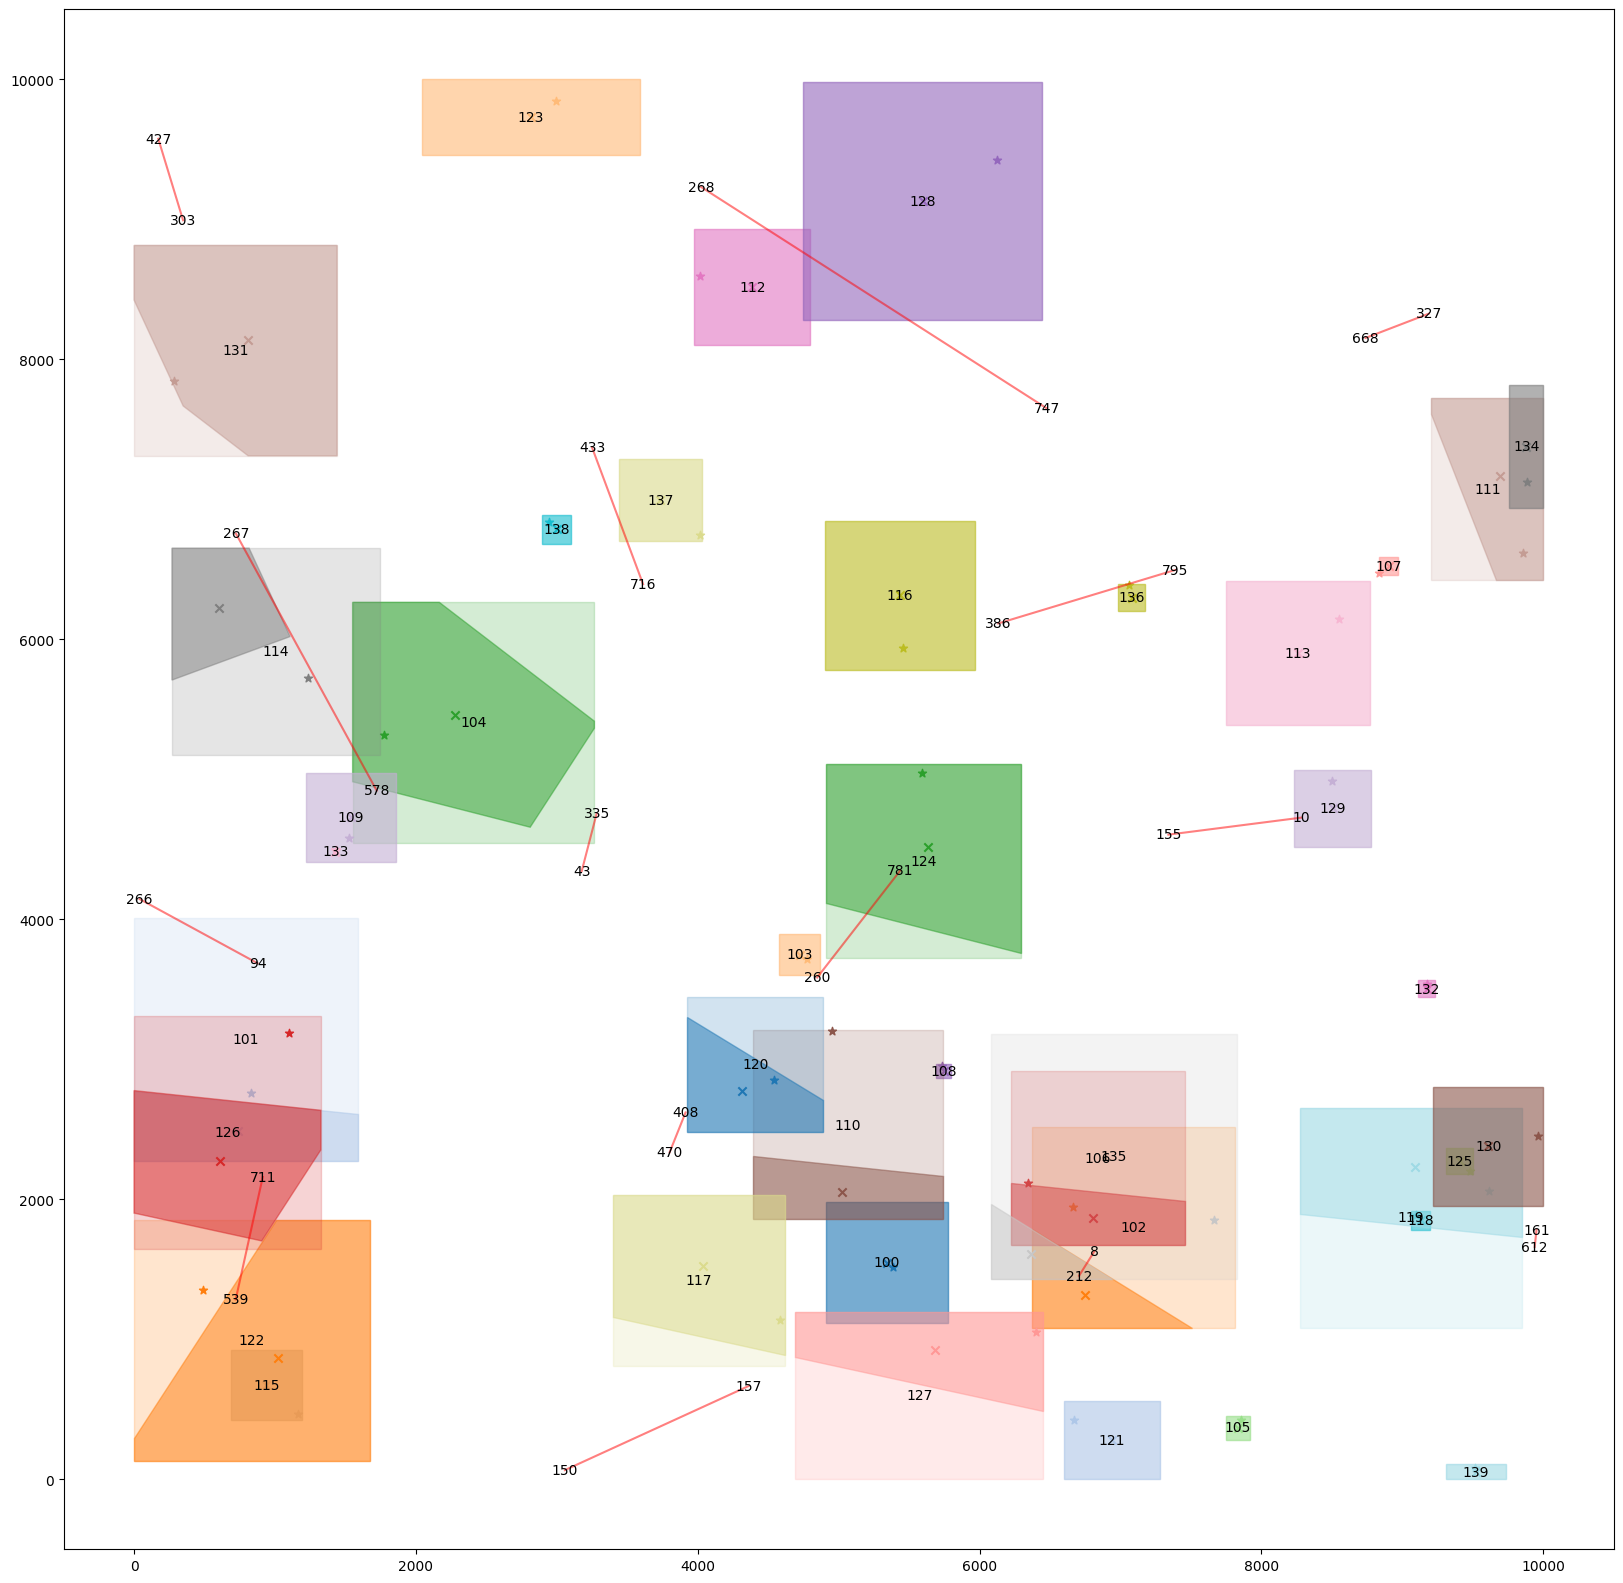

In [58]:
# ポリゴンを描画
plt.figure(figsize=(20, 20))
# for myp in my_polygons.values():
#     polygon = myp.polygon
#     x, y = polygon.exterior.xy
#     plt.fill(x, y, alpha=0.5)
# for interior in polygon.interiors:
#     x, y = interior.xy
#     plt.fill(x, y, alpha=0.5)
# coordinates

for p1, p2, c1, c2 in selected_pair_coordinates:
    x1, y1 = c1
    x2, y2 = c2
    plt.plot([x1, x2], [y1, y2], color="red", alpha=0.5)
    plt.text(x1, y1, str(p1), fontsize=10, ha="center", va="center")
    plt.text(x2, y2, str(p2), fontsize=10, ha="center", va="center")

for i in range(100, 140):
    color = matplotlib.cm.tab20(i % 20)
    polygon = my_polygons[i].polygon
    x, y = polygon.exterior.xy
    plt.fill(x, y, alpha=0.5, color=color)
    x, y = env.cneter_points[i]
    plt.text(x, y, str(my_polygons[i].ind), fontsize=10, ha="center", va="center")

    x, y = env.coordinates[i]
    plt.scatter(x, y, color=color, label="coordinates", marker="*")
    x, y = env.cneter_points[i]
    # plt.scatter(x, y, color=color, label="center points", marker="o")
    x, y = estimate_coordinate[i]
    plt.scatter(x, y, color=color, label="estimate points", marker="x")
    l, r, t, b = env.rectangles[i]
    plt.fill([l, r, r, l], [t, t, b, b], alpha=0.2, color=color)
plt.show()